# Linear Regression from Scratch

A Python-first derivation and implementation of ordinary least squares, Gaussian maximum likelihood, coefficient uncertainty, and core regression diagnostics.

## 1. Linear model and assumptions

In matrix form,

$$\mathbf y=X\boldsymbol\beta+\boldsymbol\varepsilon,$$

where $\mathbf y$ is $n\times1$, $X$ is the $n\times p$ design matrix, and $\boldsymbol\beta$ contains the unknown coefficients. For classical inference we assume

$$E(\boldsymbol\varepsilon\mid X)=0,\qquad \operatorname{Var}(\boldsymbol\varepsilon\mid X)=\sigma^2I_n,$$

with independent normal errors when exact t and F inference is required. The columns of $X$ must be linearly independent.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize

rng = np.random.default_rng(42)

## 2. Least-squares estimator $\widehat\beta$

Ordinary least squares minimizes

$$RSS(\boldsymbol\beta)=(\mathbf y-X\boldsymbol\beta)^T(\mathbf y-X\boldsymbol\beta).$$

Differentiating gives

$$\frac{\partial RSS}{\partial\boldsymbol\beta}=-2X^T(\mathbf y-X\boldsymbol\beta).$$

Setting the gradient equal to zero produces the normal equations $X^TX\widehat\beta=X^T\mathbf y$. If $X$ has full column rank,

$$\boxed{\widehat\boldsymbol\beta=(X^TX)^{-1}X^T\mathbf y}.$$

In numerical code, solving the equations or using QR/SVD-based least squares is more stable than explicitly forming the inverse.

## 3. Gaussian likelihood and MLE

If $\boldsymbol\varepsilon\sim N(0,\sigma^2I_n)$,

$$\ell(\boldsymbol\beta,\sigma^2)=-\frac n2\log(2\pi)-\frac n2\log(\sigma^2)-\frac{RSS(\boldsymbol\beta)}{2\sigma^2}.$$

For fixed $\sigma^2$, maximizing the likelihood is equivalent to minimizing RSS. Therefore the Gaussian MLE of $\boldsymbol\beta$ is the OLS estimator. The variance estimators differ by denominator:

$$\widehat\sigma^2_{MLE}=RSS/n,\qquad s^2=RSS/(n-p).$$

The first is the likelihood maximizer; the second is unbiased under the classical model and is used for coefficient standard errors.

## 4. Reproducible data example

In [2]:
n = 120
x1 = rng.normal(size=n)
x2 = rng.uniform(-2, 2, size=n)
X = np.column_stack([np.ones(n), x1, x2])
coefficient_names = ["Intercept", "x1", "x2"]
beta_true = np.array([1.5, 2.0, -0.8])
sigma_true = 1.2
y = X @ beta_true + rng.normal(scale=sigma_true, size=n)

pd.DataFrame({"y": y, "x1": x1, "x2": x2}).head()

,y,x1,x2
0,0.862465,0.304717,-1.662223
1,-0.505751,-1.039984,-0.336770
2,3.192840,0.750451,-1.833543
3,2.765031,0.940565,-0.024037
4,-2.909859,-1.951035,-0.680555


## 5. Fit from scratch

After estimating $\widehat\beta$, compute fitted values $\widehat y=X\widehat\beta$, residuals $e=y-\widehat y$, and $RSS=e^Te$. The estimated covariance matrix is

$$\widehat{\operatorname{Cov}}(\widehat\beta)=s^2(X^TX)^{-1}.$$

Its diagonal gives the squared coefficient standard errors.

In [3]:
def fit_ols(X, y, coefficient_names=None, confidence=0.95):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    if X.ndim != 2 or y.ndim != 1 or X.shape[0] != y.size:
        raise ValueError("X must be 2D and y must be a matching 1D vector")
    n, p = X.shape
    if np.linalg.matrix_rank(X) < p:
        raise ValueError("X is rank deficient; coefficients are not uniquely estimable")
    if n <= p:
        raise ValueError("residual degrees of freedom must be positive")

    xtx = X.T @ X
    beta_hat = np.linalg.solve(xtx, X.T @ y)
    fitted = X @ beta_hat
    residuals = y - fitted
    rss = residuals @ residuals
    df_resid = n - p
    sigma2_mle = rss / n
    sigma2_unbiased = rss / df_resid
    xtx_inverse = np.linalg.solve(xtx, np.eye(p))
    covariance = sigma2_unbiased * xtx_inverse
    standard_errors = np.sqrt(np.diag(covariance))
    t_statistics = beta_hat / standard_errors
    p_values = 2 * stats.t.sf(np.abs(t_statistics), df=df_resid)
    critical_value = stats.t.ppf(1 - (1 - confidence) / 2, df=df_resid)
    ci_low = beta_hat - critical_value * standard_errors
    ci_high = beta_hat + critical_value * standard_errors

    tss = np.sum((y - y.mean()) ** 2)
    r_squared = 1 - rss / tss
    adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / df_resid
    df_model = p - 1  # The first column is the intercept in this notebook.
    f_statistic = ((tss - rss) / df_model) / (rss / df_resid) if df_model > 0 else np.nan
    f_p_value = stats.f.sf(f_statistic, df_model, df_resid) if df_model > 0 else np.nan
    names = coefficient_names or [f"beta_{j}" for j in range(p)]
    table = pd.DataFrame({
        "estimate": beta_hat,
        "std_error": standard_errors,
        "t_statistic": t_statistics,
        "p_value": p_values,
        "ci_low": ci_low,
        "ci_high": ci_high,
    }, index=names)

    return {
        "beta_hat": beta_hat, "fitted": fitted, "residuals": residuals,
        "rss": rss, "df_resid": df_resid, "sigma2_mle": sigma2_mle,
        "sigma2_unbiased": sigma2_unbiased, "covariance": covariance,
        "r_squared": r_squared, "adjusted_r_squared": adjusted_r_squared,
        "df_model": df_model, "f_statistic": f_statistic, "f_p_value": f_p_value,
        "coefficient_table": table, "xtx_inverse": xtx_inverse,
    }

fit = fit_ols(X, y, coefficient_names)
fit["coefficient_table"].round(4)

,estimate,std_error,t_statistic,p_value,ci_low,ci_high
Intercept,1.5491,0.1156,13.4059,0.0,1.3202,1.7779
x1,1.9872,0.1484,13.3871,0.0,1.6932,2.2812
x2,-0.6859,0.0959,-7.1486,0.0,-0.8759,-0.4959


In [4]:
model_summary = pd.Series({
    "RSS": fit["rss"],
    "sigma_squared_MLE (RSS/n)": fit["sigma2_mle"],
    "unbiased_s_squared (RSS/(n-p))": fit["sigma2_unbiased"],
    "residual_standard_error": np.sqrt(fit["sigma2_unbiased"]),
    "R_squared": fit["r_squared"],
    "adjusted_R_squared": fit["adjusted_r_squared"],
    "F_statistic": fit["f_statistic"],
    "F_test_p_value": fit["f_p_value"],
})
print(model_summary.round(4))

coefficient_covariance = pd.DataFrame(
    fit["covariance"], index=coefficient_names, columns=coefficient_names
)
coefficient_covariance.round(4)

RSS                               186.2670
sigma_squared_MLE (RSS/n)           1.5522
unbiased_s_squared (RSS/(n-p))      1.5920
residual_standard_error             1.2618
R_squared                           0.6426
adjusted_R_squared                  0.6365
F_statistic                       105.1696
F_test_p_value                      0.0000
dtype: float64


,Intercept,x1,x2
Intercept,0.0134,0.0013,0.0002
x1,0.0013,0.0220,-0.0017
x2,0.0002,-0.0017,0.0092


## 6. Verify OLS and MLE numerically

`numpy.linalg.lstsq` uses a stable least-squares algorithm. Direct numerical maximization of the Gaussian likelihood provides a second independent check. We optimize $\log\sigma$ so that the fitted standard deviation is always positive.

In [5]:
beta_lstsq, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

def gaussian_negative_log_likelihood(parameters, X, y):
    beta = parameters[:-1]
    sigma = np.exp(parameters[-1])
    residuals = y - X @ beta
    return 0.5 * y.size * np.log(2 * np.pi * sigma**2) + (residuals @ residuals) / (2 * sigma**2)

initial = np.r_[fit["beta_hat"], np.log(np.sqrt(fit["sigma2_mle"]))]
mle_result = minimize(gaussian_negative_log_likelihood, initial, args=(X, y), method="BFGS")
beta_mle_numeric = mle_result.x[:-1]
sigma2_mle_numeric = np.exp(2 * mle_result.x[-1])

verification = pd.DataFrame({
    "normal_equations": fit["beta_hat"],
    "numpy_lstsq": beta_lstsq,
    "numerical_MLE": beta_mle_numeric,
}, index=coefficient_names)
verification.round(6)

,normal_equations,numpy_lstsq,numerical_MLE
Intercept,1.549076,1.549076,1.549076
x1,1.987208,1.987208,1.987208
x2,-0.685905,-0.685905,-0.685905


## 7. Confidence interval for the mean and prediction interval

For a new predictor row $x_0^T$, the fitted mean is $\widehat y_0=x_0^T\widehat\beta$. Its standard error is

$$SE_{mean}=s\sqrt{x_0^T(X^TX)^{-1}x_0}.$$

A future individual response also contains irreducible error, so

$$SE_{pred}=s\sqrt{1+x_0^T(X^TX)^{-1}x_0}.$$

The prediction interval is therefore wider than the confidence interval for the conditional mean.

In [6]:
def regression_intervals(fit, x0, confidence=0.95):
    x0 = np.asarray(x0, dtype=float)
    mean_prediction = x0 @ fit["beta_hat"]
    leverage = x0 @ fit["xtx_inverse"] @ x0
    s = np.sqrt(fit["sigma2_unbiased"])
    critical_value = stats.t.ppf(1 - (1 - confidence) / 2, fit["df_resid"])
    mean_margin = critical_value * s * np.sqrt(leverage)
    prediction_margin = critical_value * s * np.sqrt(1 + leverage)
    return pd.Series({
        "fitted_mean": mean_prediction,
        "mean_CI_low": mean_prediction - mean_margin,
        "mean_CI_high": mean_prediction + mean_margin,
        "prediction_low": mean_prediction - prediction_margin,
        "prediction_high": mean_prediction + prediction_margin,
    })

regression_intervals(fit, x0=[1, 0.5, -0.5]).round(4)

fitted_mean        2.8856
mean_CI_low        2.5850
mean_CI_high       3.1863
prediction_low     0.3688
prediction_high    5.4025
dtype: float64

## 8. Core diagnostics

Residuals versus fitted values help reveal nonlinearity and unequal variance. A normal Q-Q plot assesses whether residual tails are compatible with the Gaussian assumption used for exact small-sample inference. Diagnostics should be interpreted as patterns, not as pass/fail decorations.

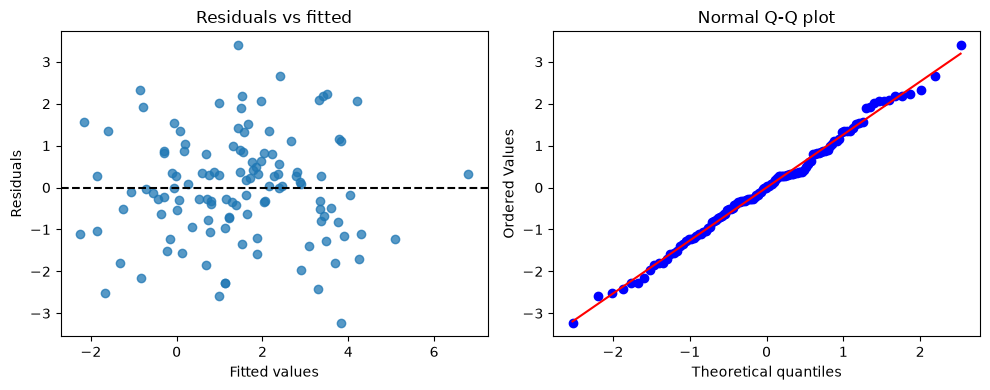

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(fit["fitted"], fit["residuals"], alpha=0.75)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set(xlabel="Fitted values", ylabel="Residuals", title="Residuals vs fitted")
stats.probplot(fit["residuals"], dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q plot")
fig.tight_layout()
plt.show()

## 9. What was estimated?

- $\widehat\beta$ was obtained by minimizing squared errors.
- Under normal errors, the same $\widehat\beta$ is the maximum likelihood estimator.
- Fitted values and residuals produced RSS.
- $RSS/n$ estimated $\sigma^2$ by MLE, while $RSS/(n-p)$ gave the unbiased estimator used for inference.
- $s^2(X^TX)^{-1}$ produced the coefficient covariance matrix, standard errors, t statistics, p-values, and confidence intervals.
- The overall F-test assessed whether the slope coefficients are jointly zero.
- Confidence and prediction intervals quantified two distinct types of uncertainty.